# Post-hoc edge inference via shared-embedding link prediction (node2vec)

This notebook demonstrates **post-hoc, shared-embedding** function -> function edge inference using `MagnitudeEdgeKGE` (now a node2vec-style link predictor; the class name is kept for backward compatibility).

Workflow:
1. Train a GSNN on a partial graph.
2. Run `MagnitudeEdgeInferer` to accumulate activation/gradient magnitude correlations.
3. Threshold MEI scores into inferred positive edges.
4. Pool inferred edges with kept-graph edges into one augmented directed graph.
5. Learn a single shared node embedding table by skip-gram with negative sampling on random walks.
6. Score held-out edges by the dot product of node embeddings.

Same converging-tier DAG setup as notebooks 13-16 (**12 inputs -> 24 function nodes -> 12 outputs**, **16 held-out** edges).

No `complex2` dependency.

In [75]:
from matplotlib import pyplot as plt
import numpy as np
import networkx as nx
import torch

from gsnn.models.GSNN import GSNN
from gsnn.simulate.nx2pyg import nx2pyg
from gsnn.simulate.simulate import simulate
from gsnn.optim.MagnitudeEdgeInferer import MagnitudeEdgeInferer
from gsnn.optim.MagnitudeEdgeKGE import MagnitudeEdgeKGE

from sklearn.metrics import roc_auc_score, roc_curve

torch.manual_seed(0)
np.random.seed(0)

device = 'cuda' if torch.cuda.is_available() else 'cpu'

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Build ground-truth graph and simulate data

In [76]:
def build_convergence_graph(n_tier_a=6):
    n = n_tier_a
    G = nx.DiGraph()
    func_func_edges_TRUE = []
    input_nodes = [f'in{i}' for i in range(n)]
    tier_a = [f'f{i}' for i in range(n)]
    tier_b = [f'f{n + k}' for k in range(n - 1)]
    tier_c = [f'f{2 * n - 1}']
    function_nodes = tier_a + tier_b + tier_c
    output_nodes = [f'o{k}' for k in range(n)]
    for i, u in enumerate(input_nodes):
        G.add_edge(u, tier_a[i])
    for k in range(n - 1):
        b = tier_b[k]
        for parent in (tier_a[k], tier_a[k + 1]):
            G.add_edge(parent, b)
            func_func_edges_TRUE.append((parent, b))
    sink = tier_c[0]
    for b in tier_b:
        G.add_edge(b, sink)
        func_func_edges_TRUE.append((b, sink))
    for k, b in enumerate(tier_b):
        G.add_edge(b, output_nodes[k])
    G.add_edge(sink, output_nodes[n - 1])
    return G, input_nodes, function_nodes, output_nodes, func_func_edges_TRUE

def default_held_out_edges(n_tier_a, b2sink_stride=2):
    n = n_tier_a
    sink = f'f{2 * n - 1}'
    held = [(f'f{k}', f'f{n + k}') for k in range(1, n - 1)]
    held += [(f'f{n + k}', sink) for k in range(0, n - 1, b2sink_stride)]
    return held

N_TIER_A = 12
G, input_nodes, function_nodes, output_nodes, func_func_edges_TRUE = build_convergence_graph(N_TIER_A)
N_FUNC = len(function_nodes)
HELD_OUT_EDGES = default_held_out_edges(N_TIER_A)

x_train, x_test, y_train, y_test = simulate(
    G, n_train=2000, n_test=500,
    input_nodes=input_nodes, output_nodes=output_nodes,
    noise_scale=0.15, special_functions=None,
)
x_train = torch.tensor(x_train, dtype=torch.float32).to(device)
x_test = torch.tensor(x_test, dtype=torch.float32).to(device)
y_train = torch.tensor(y_train, dtype=torch.float32).to(device)
y_test = torch.tensor(y_test, dtype=torch.float32).to(device)
y_mu, y_std = y_train.mean(0), y_train.std(0)
y_train = (y_train - y_mu) / (y_std + 1e-8)
y_test = (y_test - y_mu) / (y_std + 1e-8)

held_out_set = set(HELD_OUT_EDGES)
G_partial = G.copy()
G_partial.remove_edges_from(HELD_OUT_EDGES)
data = nx2pyg(G_partial, input_nodes, function_nodes, output_nodes)
kept_edges = [e for e in func_func_edges_TRUE if e not in held_out_set]
kept_ff_set = set(kept_edges)

sink = f'f{2 * N_TIER_A - 1}'
left_merge = [e for e in HELD_OUT_EDGES if e[1] != sink]
b2sink = [e for e in HELD_OUT_EDGES if e[1] == sink]
rng = np.random.default_rng(0)
rng.shuffle(left_merge); rng.shuffle(b2sink)
edges_val = left_merge[:len(left_merge)//2] + b2sink[:len(b2sink)//2]
edges_test = left_merge[len(left_merge)//2:] + b2sink[len(b2sink)//2:]
held_out_benchmark = set(edges_val) | set(edges_test)

print(f'functions: {N_FUNC} | held-out val/test: {len(edges_val)}/{len(edges_test)}')

functions: 24 | held-out val/test: 8/8


## Train GSNN (no auxiliary edge inference)

In [77]:
BATCH_SIZE = 64

model_kwargs = dict(
    channels=8, layers=6, share_layers=False, bias=True,
    add_function_self_edges=True, norm='groupbatch', dropout=0.,
    nonlin=torch.nn.ELU, node_mlp=False, checkpoint=False,
)

model = GSNN(data.edge_index_dict, data.node_names_dict, **model_kwargs).to(device)

train_loader = torch.utils.data.DataLoader(
    torch.utils.data.TensorDataset(x_train, y_train),
    batch_size=BATCH_SIZE, shuffle=True, drop_last=True,
)
infer_loader = torch.utils.data.DataLoader(
    torch.utils.data.TensorDataset(x_train, y_train),
    batch_size=BATCH_SIZE, shuffle=False, drop_last=True,
)
gsnn_optim = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=0)
crit = torch.nn.MSELoss()

n_epochs = 30
for epoch in range(n_epochs):
    model.train()
    for x_batch, y_batch in train_loader:
        gsnn_optim.zero_grad()
        loss = crit(model(x_batch), y_batch)
        loss.backward()
        gsnn_optim.step()
    if epoch == 0 or (epoch + 1) % 10 == 0 or epoch == n_epochs - 1:
        model.eval()
        with torch.no_grad():
            mse = crit(model(x_test), y_test).item()
        print(f'epoch {epoch+1:2d} | test MSE {mse:.4f}')

epoch  1 | test MSE 0.7987
epoch 10 | test MSE 0.4809
epoch 20 | test MSE 0.4842
epoch 30 | test MSE 0.4804


## Fit MagnitudeEdgeInferer and inspect inferred positives

In [81]:
mei = MagnitudeEdgeInferer(model, data, reduction='l1')
mei.fit(infer_loader, crit=crit, device=device, verbose=False)

res_corr = mei.evaluate(layer_agg='max', score='corr')
res_partial = mei.evaluate(layer_agg='max', score='partial')

print(f'MEI samples: {mei.n}')
print('\nTop 10 inferred edges by corr (non-kept):')
display(res_corr[~res_corr['has_edge']].head(10)[
    ['src_func', 'dst_func', 'corr', 'p_value', 'q_value']
])

n_fdr = ((res_corr['q_value'] <= 0.05) & ~res_corr['has_edge']).sum()
print(f'\nFDR-significant non-kept edges (alpha=0.05): {n_fdr}')

MEI samples: 1984

Top 10 inferred edges by corr (non-kept):


,src_func,dst_func,corr,p_value,q_value
0,f4,f16,0.889384,0.0,0.0
1,f2,f14,0.881459,0.0,0.0
2,f2,f3,0.878537,0.0,0.0
3,f10,f22,0.876956,0.0,0.0
4,f1,f13,0.866949,0.0,0.0
5,f18,f8,0.863582,0.0,0.0
6,f3,f15,0.863015,0.0,0.0
7,f18,f19,0.862077,0.0,0.0
8,f10,f11,0.861264,0.0,0.0
9,f4,f5,0.857633,0.0,0.0



FDR-significant non-kept edges (alpha=0.05): 106


## Train MagnitudeEdgeKGE (shared embedding, kept + inferred edges pooled)

Held-out val/test edges are excluded from the inferred positive set to prevent leakage.
A single embedding table is learned by skip-gram with negative sampling on random walks
over the augmented graph. All edges - kept and inferred - push the same embeddings.

Random-walk transition probabilities are weighted by `max(MEI corr, 0) ** walk_alpha`
so the continuous MEI signal influences walk frequency. Larger `walk_alpha` concentrates
walks on high-correlation edges; `walk_alpha=0` is equivalent to uniform walks
(`walk_corr_weighted=False`). Kept edges receive a weight of at least the strongest
inferred-edge weight (or override via `kept_edge_weight`).

In [92]:
kge = MagnitudeEdgeKGE(
    mei,
    embedding_dim=32,
    score='corr',
    layer_agg='max',
    mining_strategy='fdr',
    top_k_per_target=0,
    fdr_alpha=0.00001,
    walks_per_node=20,
    walk_length=10,
    window_size=5,
    n_negatives=25,
    walk_undirected=True,
    walk_corr_weighted=True,
    walk_alpha=2.0,
    kept_edge_weight=None,
    lr=1e-1,
    weight_decay=1e-4,
    exclude_edges=held_out_benchmark,
).to(device)

print(f'KGE params: {sum(p.numel() for p in kge.parameters())}')
print(f'true edges: {kge.true_heads.numel()} | inferred edges: {kge.inferred_heads.numel()}')

history = kge.fit(
    n_epochs=200,
    batch_size=2048,
    validation_edges=edges_val,
    verbose=True,
)
kge.load_best()

KGE params: 768
true edges: 17 | inferred edges: 62
epoch    1/200 | pairs  29758 | loss 1.2292 | val AUC 0.701
epoch   20/200 | pairs  29778 | loss 1.1846 | val AUC 0.681
epoch   40/200 | pairs  29838 | loss 1.1777 | val AUC 0.703


KeyboardInterrupt: 

## Validation AUC vs epoch

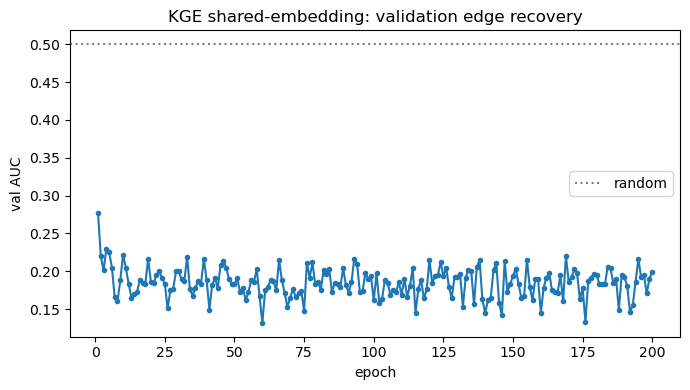

In [86]:
if 'val_auc' in history:
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.plot(range(1, len(history['val_auc']) + 1), history['val_auc'], marker='o', ms=3)
    ax.axhline(0.5, color='k', ls=':', alpha=0.5, label='random')
    ax.set_xlabel('epoch'); ax.set_ylabel('val AUC')
    ax.set_title('KGE shared-embedding: validation edge recovery')
    ax.legend(); plt.tight_layout(); plt.show()

## Head-to-head comparison on test held-out edges

In [87]:
def roc_auc_for_edges(res_df, positive_edges, score_col='score'):
    pos_set = set(positive_edges)
    pos = res_df[res_df.apply(lambda r: (r['src_func'], r['dst_func']) in pos_set, axis=1)][score_col].dropna().values
    neg = res_df[~res_df.apply(lambda r: (r['src_func'], r['dst_func']) in pos_set, axis=1)]
    neg = neg[neg.apply(lambda r: (r['src_func'], r['dst_func']) not in kept_ff_set, axis=1)][score_col].dropna().values
    if len(pos) == 0 or len(neg) == 0:
        return float('nan')
    return roc_auc_score(
        np.concatenate([np.ones(len(pos)), np.zeros(len(neg))]),
        np.concatenate([pos, neg]),
    )

def fit_kge_variant(name, *, edges_to_use='joint', n_epochs=200):
    """Refit a KGE variant. ``edges_to_use`` controls the positive pool."""
    k = MagnitudeEdgeKGE(
        mei,
        embedding_dim=32,
        score='corr',
        layer_agg='max',
        mining_strategy='fdr',
        fdr_alpha=0.05,
        walks_per_node=20, walk_length=10, window_size=5, n_negatives=5,
        walk_undirected=True, walk_corr_weighted=True, walk_alpha=2.0,
        lr=1e-2, weight_decay=1e-4,
        exclude_edges=held_out_benchmark,
    ).to(device)
    if edges_to_use == 'inferred':
        k.pos_heads = k.inferred_heads
        k.pos_tails = k.inferred_tails
    elif edges_to_use == 'true':
        k.pos_heads = k.true_heads
        k.pos_tails = k.true_tails
    pm = torch.zeros(k.N, k.N, dtype=torch.bool)
    if k.pos_heads.numel() > 0:
        pm[k.pos_heads, k.pos_tails] = True
    k.pos_mask = pm
    k._build_adjacency()
    k.fit(n_epochs=n_epochs, batch_size=2048, validation_edges=edges_val, verbose=False)
    k.load_best()
    return k

res_kge_joint = kge.evaluate()
kge_inferred_only = fit_kge_variant('inferred-only', edges_to_use='inferred')
kge_true_only = fit_kge_variant('true-only', edges_to_use='true')
res_kge_inf = kge_inferred_only.evaluate()
res_kge_true = kge_true_only.evaluate()

results = {
    'MEI corr': (res_corr, 'corr'),
    'MEI partial': (res_partial, 'corr'),
    'KGE joint (kept + inferred)': (res_kge_joint, 'score'),
    'KGE inferred-only': (res_kge_inf, 'score'),
    'KGE true-only': (res_kge_true, 'score'),
}

print('Test-set ROC-AUC:')
for name, (df, col) in results.items():
    print(f'  {name:28s}: {roc_auc_for_edges(df, edges_test, score_col=col):.3f}')

print('\nWithin-target ranking (test held-out):')
for name, (df, col) in results.items():
    score_col = 'score' if col == 'score' else col
    if col != 'score':
        df = df.rename(columns={'corr': 'score'})
    _, summary = MagnitudeEdgeKGE.evaluate_target_ranking(df, edges_test, score_col='score')
    print(f"  {name:28s}: MRR={summary['mrr']:.3f} top@1={summary['top@1']:.3f}")

Test-set ROC-AUC:
  MEI corr                    : 0.872
  MEI partial                 : 0.873
  KGE joint (kept + inferred) : 0.463
  KGE inferred-only           : 0.634
  KGE true-only               : 0.190

Within-target ranking (test held-out):
  MEI corr                    : MRR=0.672 top@1=0.625
  MEI partial                 : MRR=0.674 top@1=0.625
  KGE joint (kept + inferred) : MRR=0.083 top@1=0.000
  KGE inferred-only           : MRR=0.125 top@1=0.000
  KGE true-only               : MRR=0.065 top@1=0.000


## ROC curves

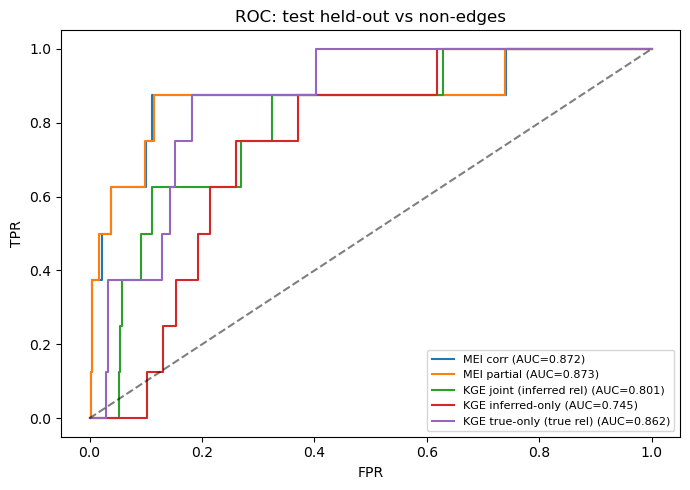

In [ ]:
fig, ax = plt.subplots(figsize=(7, 5))
for name, (df, col) in results.items():
    pos_set = set(edges_test)
    pos = df[df.apply(lambda r: (r['src_func'], r['dst_func']) in pos_set, axis=1)][col].dropna().values
    neg = df[~df.apply(lambda r: (r['src_func'], r['dst_func']) in pos_set, axis=1)]
    neg = neg[neg.apply(lambda r: (r['src_func'], r['dst_func']) not in kept_ff_set, axis=1)][col].dropna().values
    if len(pos) == 0 or len(neg) == 0:
        continue
    y_true = np.concatenate([np.ones(len(pos)), np.zeros(len(neg))])
    y_score = np.concatenate([pos, neg])
    auc = roc_auc_score(y_true, y_score)
    fpr, tpr, _ = roc_curve(y_true, y_score)
    ax.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})')
ax.plot([0, 1], [0, 1], 'k--', alpha=0.5)
ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
ax.set_title('ROC: test held-out vs non-edges')
ax.legend(fontsize=8); plt.tight_layout(); plt.show()

## Discussion

`MagnitudeEdgeKGE` is a **post-hoc shared-embedding link predictor** on top of Tier-0 magnitude correlation:

1. **MEI mining** - FDR-significant (or top-K) non-kept edges from `MagnitudeEdgeInferer` become inferred positives.
2. **Structural prior** - kept function-function edges and inferred edges are pooled into a single augmented directed graph; every edge pushes the same node embedding table.
3. **Anti-leakage** - pass held-out benchmark edges via `exclude_edges` so they are never trained as inferred positives.
4. **Scalability** - parameter count is `O(N * d)` (one shared embedding table) rather than `O(N^2)`.

Compare ablations:
- **MEI corr / partial** - direct correlation scores (no embedding).
- **KGE true-only** - structural link prediction baseline trained on kept edges only.
- **KGE inferred-only** - MEI-mined positives only, no graph prior.
- **KGE joint** - both pooled into one shared embedding space.

The shared embedding will only beat raw MEI correlation when (a) the kept graph is large and densely structured (so transitivity through kept edges constrains test edges) and (b) MEI per-edge estimates are noisy enough that pooling helps. On small toy graphs MEI correlation is hard to beat because the mining step discards continuous score information.